EDA
 ↓
Missing values ✓
 ↓
Duplicates ✓
 ↓
Data types ✓
 ↓
Outlier / invalid-value check ← YOU ARE HERE ✓ there is no outlier in this data set 
 ↓
Handle missing values ✓
 ↓
Encode categorical columns
 ↓
Select X and y
 ↓
Train/Test Split
 ↓
Feature Scaling
 ↓
KNN

# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("corona_tested_individuals.csv")

C:\Users\Vinodh T\AppData\Local\Temp\ipykernel_8724\2709338479.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("corona_tested_individuals.csv")


In [3]:
df.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  object 
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  object 
 7   age_60_and_above     151528 non-null  object 
 8   gender               259285 non-null  object 
 9   test_indication      278848 non-null  object 
dtypes: float64(5), object(5)
memory usage: 21.3+ MB


In [5]:
df.describe()

,cough,fever,sore_throat,shortness_of_breath,head_ache
count,278596.000000,278596.000000,278847.000000,278847.000000,278847.000000
mean,0.151574,0.078077,0.006907,0.005655,0.008657
std,0.358608,0.268294,0.082821,0.074990,0.092640
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.shape

(278848, 10)

In [7]:
df.columns

Index(['test_date', 'cough', 'fever', 'sore_throat', 'shortness_of_breath',
       'head_ache', 'corona_result', 'age_60_and_above', 'gender',
       'test_indication'],
      dtype='object')

In [8]:
dc = df.copy()

In [9]:
df.columns = df.columns.str.replace(" ", "_")

# CHECK DUPLICATE AND MISSING VALUES

In [10]:
dc.duplicated().sum()

np.int64(272207)

In [11]:
dc.isnull().sum()

test_date                   0
cough                     252
fever                     252
sore_throat                 1
shortness_of_breath         1
head_ache                   1
corona_result               0
age_60_and_above       127320
gender                  19563
test_indication             0
dtype: int64

In [12]:
df.describe(include="all")

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
count,278848,278596.000000,278596.000000,278847.000000,278847.000000,278847.000000,278848,151528,259285,278848
unique,51,NaN,NaN,NaN,NaN,NaN,3,2,2,3
top,2020-04-20,NaN,NaN,NaN,NaN,NaN,negative,No,female,Other
freq,10921,NaN,NaN,NaN,NaN,NaN,260227,125703,130158,242741
mean,NaN,0.151574,0.078077,0.006907,0.005655,0.008657,NaN,NaN,NaN,NaN
std,NaN,0.358608,0.268294,0.082821,0.074990,0.092640,NaN,NaN,NaN,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN


# Check DataTypes for filling the missing values 

In [13]:
dc.dtypes

test_date               object
cough                  float64
fever                  float64
sore_throat            float64
shortness_of_breath    float64
head_ache              float64
corona_result           object
age_60_and_above        object
gender                  object
test_indication         object
dtype: object

# HANDLE THE MISSING VALUES 

In [14]:
con = dc.select_dtypes(include="number").columns
print(con)

Index(['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache'], dtype='object')


In [15]:
cat = dc.select_dtypes(include="object").columns
print(cat)

Index(['test_date', 'corona_result', 'age_60_and_above', 'gender',
       'test_indication'],
      dtype='object')


In [16]:
for col in con:
    dc[col] = dc[col].fillna(dc[col].mode()[0])
print("Completed")

Completed


In [17]:
dc[con].isnull().sum()

cough                  0
fever                  0
sore_throat            0
shortness_of_breath    0
head_ache              0
dtype: int64

# HERE I HAVE TO CHANGE THE test_date DATA AS to_datetime its is not object

In [18]:
dc["test_date"] = pd.to_datetime(dc["test_date"])

In [19]:
dc.dtypes

test_date              datetime64[ns]
cough                         float64
fever                         float64
sore_throat                   float64
shortness_of_breath           float64
head_ache                     float64
corona_result                  object
age_60_and_above               object
gender                         object
test_indication                object
dtype: object

In [20]:
cat = [
    "corona_result",
    "age_60_and_above",
    "gender",
    "test_indication"
]

print(dc[cat].isnull().sum())

corona_result            0
age_60_and_above    127320
gender               19563
test_indication          0
dtype: int64


In [21]:
dc["gender"] = dc["gender"].fillna("Unknown")

In [22]:
dc["age_60_and_above"] = dc["age_60_and_above"].fillna("Unknown")

In [23]:
cat = [
    "corona_result",
    "age_60_and_above",
    "gender",
    "test_indication"
]

print(dc[cat].isnull().sum())

corona_result       0
age_60_and_above    0
gender              0
test_indication     0
dtype: int64


# checking whether your symptom columns contain values other than the valid values 0 and 1.

In [24]:
con = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache"
]
for col in con:
    invalid = dc[~dc[col].isin([0, 1]) & dc[col].notna()]
    print(col, "invalid values:", len(invalid))

cough invalid values: 0
fever invalid values: 0
sore_throat invalid values: 0
shortness_of_breath invalid values: 0
head_ache invalid values: 0


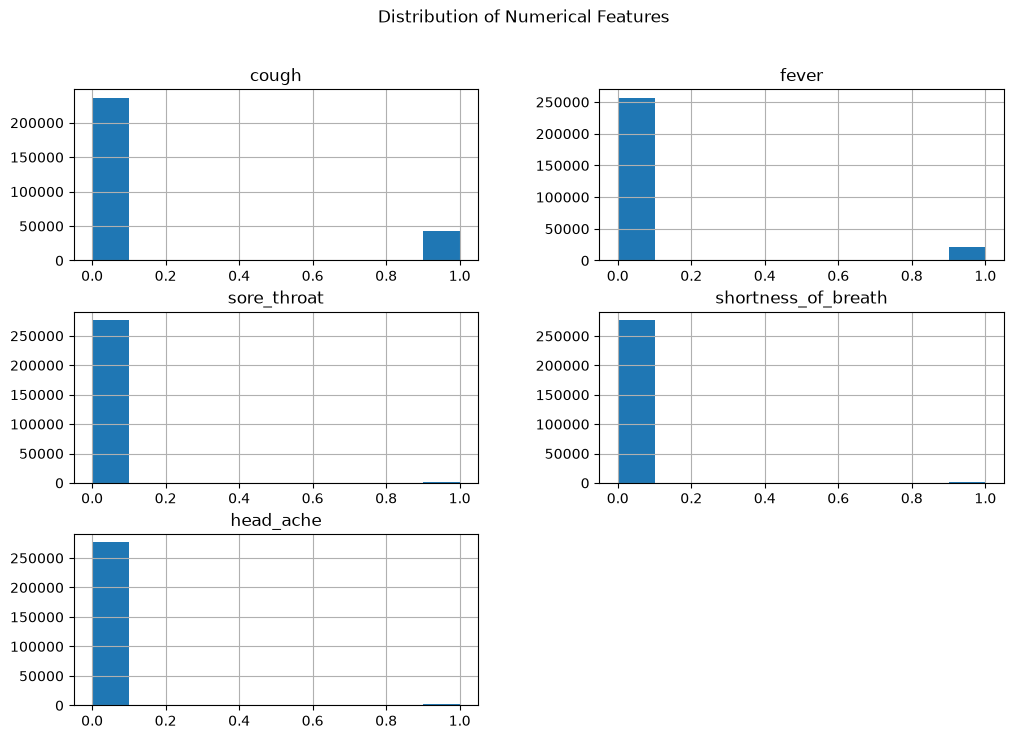

In [25]:
dc[con].hist(
    figsize=(12, 8),
    bins=10
)

plt.suptitle("Distribution of Numerical Features")
plt.show()

In [26]:
dc.duplicated()

0         False
1         False
2         False
3          True
4         False
          ...  
278843     True
278844     True
278845     True
278846     True
278847     True
Length: 278848, dtype: bool

In [27]:
dc.duplicated().sum()

np.int64(272258)

In [28]:
dc[dc.duplicated()]

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,Unknown,female,Other
5,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,Unknown,female,Other
7,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,Unknown,female,Other
11,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,Unknown,female,Other
12,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,Unknown,female,Other
...,...,...,...,...,...,...,...,...,...,...
278843,2020-03-11,0.0,0.0,0.0,0.0,0.0,negative,Unknown,Unknown,Other
278844,2020-03-11,0.0,0.0,0.0,0.0,0.0,negative,Unknown,Unknown,Other
278845,2020-03-11,0.0,0.0,0.0,0.0,0.0,positive,Unknown,Unknown,Contact with confirmed
278846,2020-03-11,0.0,0.0,0.0,0.0,0.0,other,Unknown,Unknown,Other


In [29]:
dc = dc.drop_duplicates()

In [30]:
dc.duplicated().sum()

np.int64(0)

In [31]:
print("Shape:", dc.shape)
print("Duplicates:", dc.duplicated().sum())
print("Missing values:")
print(dc.isnull().sum())

Shape: (6590, 10)
Duplicates: 0
Missing values:
test_date              0
cough                  0
fever                  0
sore_throat            0
shortness_of_breath    0
head_ache              0
corona_result          0
age_60_and_above       0
gender                 0
test_indication        0
dtype: int64


In [32]:
dc["corona_result"].value_counts()

corona_result
positive    3623
negative    2307
other        660
Name: count, dtype: int64

# categorical encoding

In [33]:
cat = ["age_60_and_above", "gender", "test_indication"]

for col in cat:
    print("\n---", col, "---")
    print(dc[col].value_counts())


--- age_60_and_above ---
age_60_and_above
No         3522
Yes        1692
Unknown    1376
Name: count, dtype: int64

--- gender ---
gender
male       2691
female     2636
Unknown    1263
Name: count, dtype: int64

--- test_indication ---
test_indication
Other                     2536
Contact with confirmed    2241
Abroad                    1813
Name: count, dtype: int64


In [34]:
dc = pd.get_dummies(
    dc,
    columns=cat,
    drop_first=True,
    dtype=int
)

# I have to make this binary classifier:

In [35]:
dc = dc[dc["corona_result"].isin(["positive", "negative"])]

In [36]:
dc["corona_result"] = dc["corona_result"].map({
    "negative": 0,
    "positive": 1
})

In [37]:
dc["corona_result"].value_counts()

corona_result
1    3623
0    2307
Name: count, dtype: int64

# Remove test_date

In [38]:
dc = dc.drop(columns=["test_date"])

In [39]:
X = dc.drop("corona_result", axis=1)
y = dc["corona_result"]

In [40]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5930, 11)
y shape: (5930,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [42]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4151, 11)
X_test: (1779, 11)
y_train: (4151,)
y_test: (1779,)


# using KNN, scaling is important

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
X_train_scaled = scaler.fit_transform(X_train)

In [45]:
X_test_scaled = scaler.transform(X_test)

In [46]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(4151, 11)
(1779, 11)


In [47]:
dc.to_csv("preprocessed_healthcare_data.csv", index=False)
print("CSV saved successfully!")

CSV saved successfully!


# KNN 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train_scaled, y_train)

print("Training completed!")

y_pred = model.predict(X_test_scaled)

print("Prediction completed!")

Training completed!
Prediction completed!


In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6632939853850478


In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[389 303]
 [296 791]]


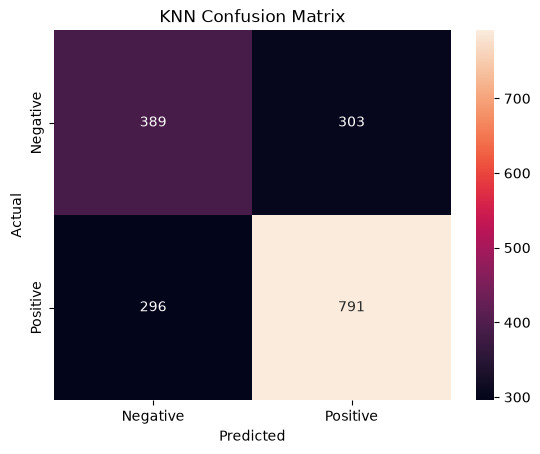

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

# LOGISTIC REGRESSION

In [52]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed!")


Logistic Regression training completed!


In [53]:
y_pred_log = log_model.predict(X_test_scaled)

print(y_pred_log)

[0 1 0 ... 1 0 1]


In [54]:
from sklearn.metrics import accuracy_score

accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", accuracy_log)

Logistic Regression Accuracy: 0.6897133220910624


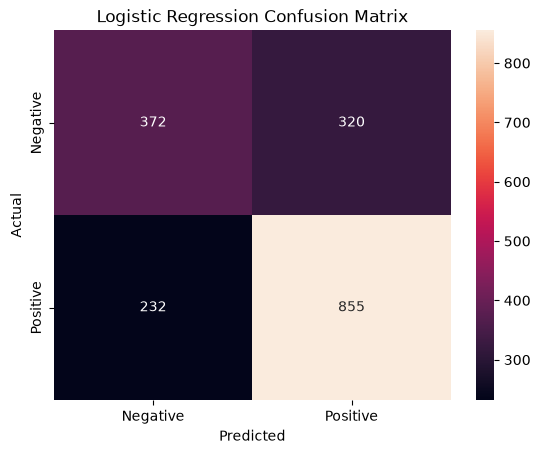

In [56]:
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

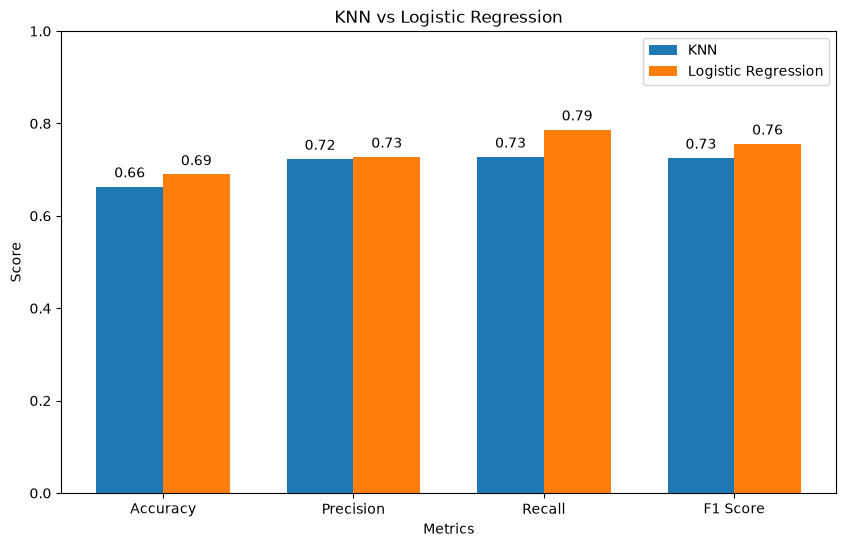

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

knn = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

logistic = [
    accuracy_score(y_test, y_pred_log),
    precision_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_log),
    f1_score(y_test, y_pred_log)
]

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, knn, width, label="KNN")
plt.bar(x + width/2, logistic, width, label="Logistic Regression")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("KNN vs Logistic Regression")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()

for i, value in enumerate(knn):
    plt.text(i - width/2, value + 0.02, f"{value:.2f}", ha="center")

for i, value in enumerate(logistic):
    plt.text(i + width/2, value + 0.02, f"{value:.2f}", ha="center")

plt.show()

In [58]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree training completed!")

y_pred_dt = dt_model.predict(X_test)

print("Prediction completed!")

Decision Tree training completed!
Prediction completed!


In [59]:
from sklearn.metrics import accuracy_score

dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.6587970770095559


In [60]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.55      0.64      0.60       692
    Positive       0.75      0.67      0.71      1087

    accuracy                           0.66      1779
   macro avg       0.65      0.66      0.65      1779
weighted avg       0.67      0.66      0.66      1779



In [61]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[446 246]
 [361 726]]


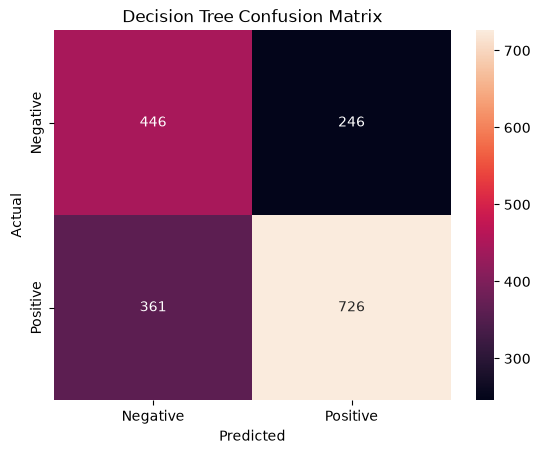

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

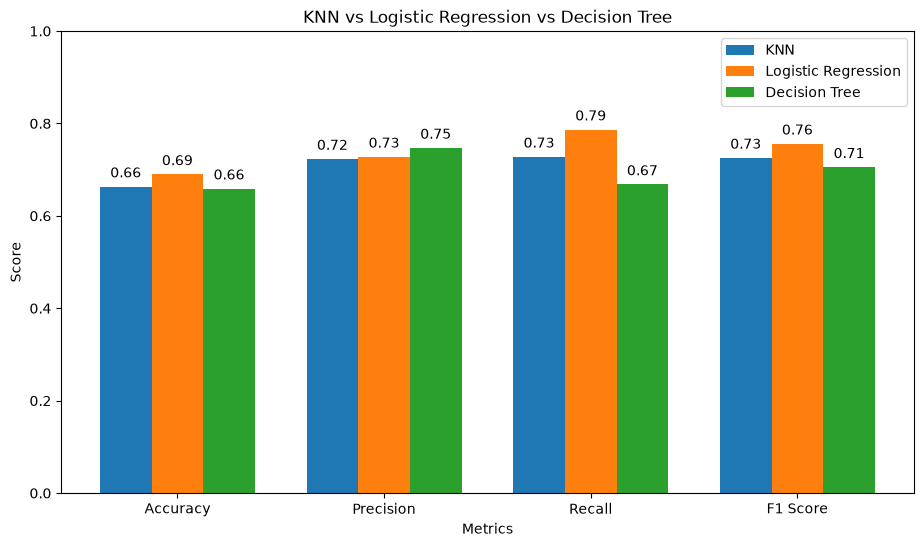

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# Calculate metrics
knn = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

logistic = [
    accuracy_score(y_test, y_pred_log),
    precision_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_log),
    f1_score(y_test, y_pred_log)
]

decision_tree = [
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt)
]

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(11, 6))

bars1 = plt.bar(x - width, knn, width, label="KNN")
bars2 = plt.bar(x, logistic, width, label="Logistic Regression")
bars3 = plt.bar(x + width, decision_tree, width, label="Decision Tree")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("KNN vs Logistic Regression vs Decision Tree")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()

# Add values on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f"{value:.2f}",
            ha="center"
        )

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=5,
    random_state=42,
    bootstrap=True,
    max_depth=5
)

rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rf.predict(X_test)

In [69]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.6975829117481731


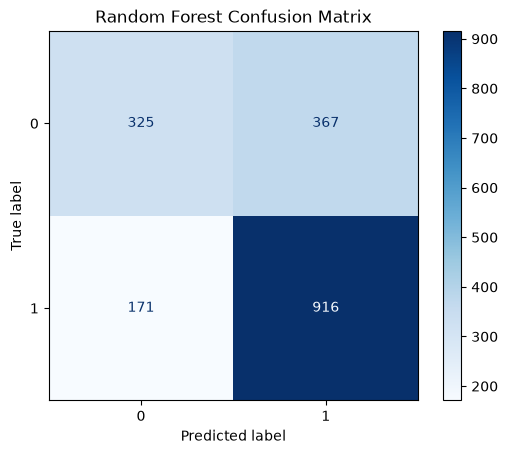

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.show()

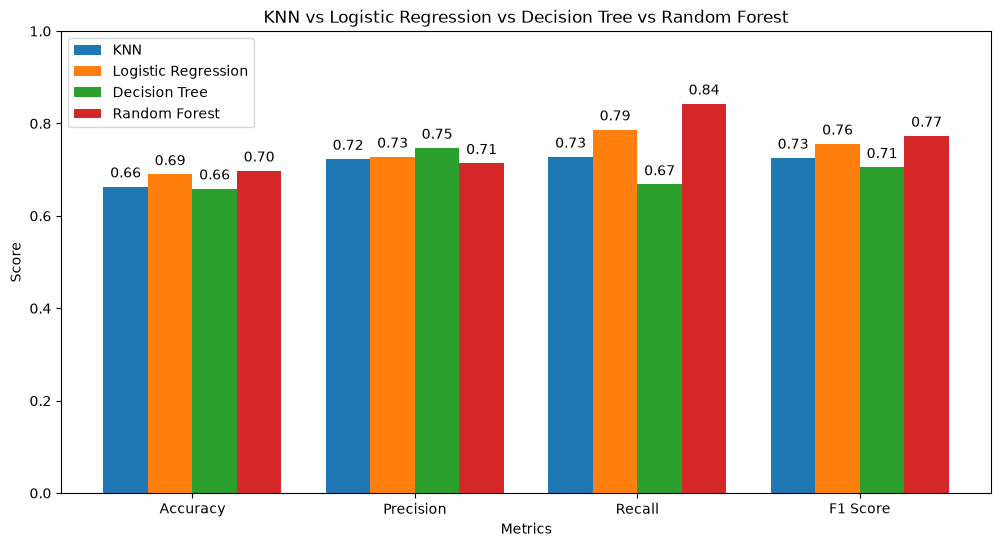

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# KNN
knn = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

# Logistic Regression
logistic = [
    accuracy_score(y_test, y_pred_log),
    precision_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_log),
    f1_score(y_test, y_pred_log)
]

# Decision Tree
decision_tree = [
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt)
]

# Random Forest
random_forest = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(metrics))
width = 0.20

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - 1.5*width, knn, width, label="KNN")
bars2 = plt.bar(x - 0.5*width, logistic, width, label="Logistic Regression")
bars3 = plt.bar(x + 0.5*width, decision_tree, width, label="Decision Tree")
bars4 = plt.bar(x + 1.5*width, random_forest, width, label="Random Forest")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("KNN vs Logistic Regression vs Decision Tree vs Random Forest")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()

# Add values on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f"{value:.2f}",
            ha="center"
        )

plt.show()